# Hotel Reservation

## Context

A significant number of hotel bookings are called-off due to cancellations or no-shows. The typical reasons for cancellations include change of plans, scheduling conflicts, etc. This is often made easier by the option to do so free of charge or preferably at a low cost which is beneficial to hotel guests but it is a less desirable and possibly revenue-diminishing factor for hotels to deal with. Such losses are particularly high on last-minute cancellations. 

The new technologies involving online booking channels have dramatically changed customers’ booking possibilities and behavior. This adds a further dimension to the challenge of how hotels handle cancellations, which are no longer limited to traditional booking and guest characteristics. 

The cancellation of bookings impact a hotel on various fronts:
* Loss of resources (revenue) when the hotel cannot resell the room.
* Additional costs of distribution channels by increasing commissions or paying for publicity to help sell these rooms.
* Lowering prices last minute, so the hotel can resell a room, resulting in reducing the profit margin.
* Human resources to make arrangements for the guests.

## Data Description
The data contains different attributes of customers' booking details. The detailed data dictionary is given below.


**Data Dictionary**

* Booking_ID: unique identifier of each booking
* no_of_adults: Number of adults
* no_of_children: Number of Children
* no_of_weekend_nights: Number of weekend nights (Saturday or Sunday) the guest stayed or booked to stay at the hotel
* no_of_week_nights: Number of week nights (Monday to Friday) the guest stayed or booked to stay at the hotel
* type_of_meal_plan: Type of meal plan booked by the customer:
    * Not Selected – No meal plan selected
    * Meal Plan 1 – Breakfast
    * Meal Plan 2 – Half board (breakfast and one other meal)
    * Meal Plan 3 – Full board (breakfast, lunch, and dinner)
* required_car_parking_space: Does the customer require a car parking space? (0 - No, 1- Yes)
* room_type_reserved: Type of room reserved by the customer. The values are ciphered (encoded) by INN Hotels.
* lead_time: Number of days between the date of booking and the arrival date
* arrival_year: Year of arrival date
* arrival_month: Month of arrival date
* arrival_date: Date of the month
* market_segment_type: Market segment designation.
* repeated_guest: Is the customer a repeated guest? (0 - No, 1- Yes)
* no_of_previous_cancellations: Number of previous bookings that were canceled by the customer prior to the current booking
* no_of_previous_bookings_not_canceled: Number of previous bookings not canceled by the customer prior to the current booking
* avg_price_per_room: Average price per day of the reservation; prices of the rooms are dynamic. (in euros)
* no_of_special_requests: Total number of special requests made by the customer (e.g. high floor, view from the room, etc)
* booking_status: Flag indicating if the booking was canceled or not. (This is the target column that we'd want to be able to predict). Use 'Canceled' as positive class and 'Not_Canceled' as negative class.

### 0) Importing necessary libraries and data

In [54]:
# To help with reading and manipulation of data
import numpy as np
import pandas as pd

# To help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# To split the data
from sklearn.model_selection import train_test_split

# To impute missing values
from sklearn.impute import SimpleImputer

# To build a Random forest classifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# To tune a model
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# To get different performance metrics
import sklearn.metrics as metrics
from sklearn.metrics import (
    recall_score,
    accuracy_score,
    precision_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    roc_curve
)

# To suppress warnings
import warnings

warnings.filterwarnings("ignore")

### 1) Perform Exploratory Data Analysis (EDA) and state your observations.

In [55]:
df = pd.read_csv("Hotel_reservation.csv")
data = df.copy()
data.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [56]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

In [57]:
# checking missing values in the data
data.isna().sum()

Booking_ID                              0
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64

### 2) Perform Data Preprocessing (10 points)

**Things to consider**:
- Missing value treatment (if needed)  

- Feature engineering (if needed)  

- Outlier detection and treatment (if needed)  

- Preparing data for modeling  

- Any other preprocessing steps (if needed)

**Hint**: 
- For `outlier processing`, you may need to deal with both numerical columns (e.g., extreme values) and categorical columns (e.g., rare categories or typos).  

- Although one advantage of Decision Tree is that it is able to handle both numerical and categorical data. However, the scikit-learn DecisionTreeClassifier implementation does not support categorical variables for now. So you may need to `process categorical columns` (e.g., create dummy variables).  

- To ensure the results are reproducible, use **`random_state=42`** when splitting

In [58]:
df['market_segment_type'].unique()

array(['Offline', 'Online', 'Corporate', 'Aviation', 'Complementary'],
      dtype=object)

In [59]:
# checking the distribution of the target variable
data["booking_status"].value_counts(normalize=True)

booking_status
Not_Canceled    0.672364
Canceled        0.327636
Name: proportion, dtype: float64

## Decision Tree Train & Tuning

### 3-1) Build a `default` `decision tree` model. Evaluate the performance of your default decision tree model on the training and the test data set. State your observation on whether the model is overfit/underfit. (5 points)

**Hint**: To ensure the results are reproducible, use **`random_state=42`** when training

In [60]:
# separating the independent and dependent variables
X = data.drop(["booking_status"], axis=1)
y = data["booking_status"]
y = (y == 'Canceled')

# creating dummy variables 
X = pd.get_dummies(X)

In [61]:
# Splitting data into training, validation and test set:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5, stratify=y)
print(X_train.shape, X_test.shape)

(29020, 36305) (7255, 36305)


In [62]:
# Checking class balance for whole data, train set, validation set, and test set
print("Target value ratio in y")
print(y.value_counts(normalize=True))
print("*" * 80)
print("Target value ratio in y_train")
print(y_train.value_counts(normalize=True))
print("*" * 80)
print("Target value ratio in y_test")
print(y_test.value_counts(normalize=True))
print("*" * 80)

Target value ratio in y
booking_status
False    0.672364
True     0.327636
Name: proportion, dtype: float64
********************************************************************************
Target value ratio in y_train
booking_status
False    0.672364
True     0.327636
Name: proportion, dtype: float64
********************************************************************************
Target value ratio in y_test
booking_status
False    0.672364
True     0.327636
Name: proportion, dtype: float64
********************************************************************************


In [63]:
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

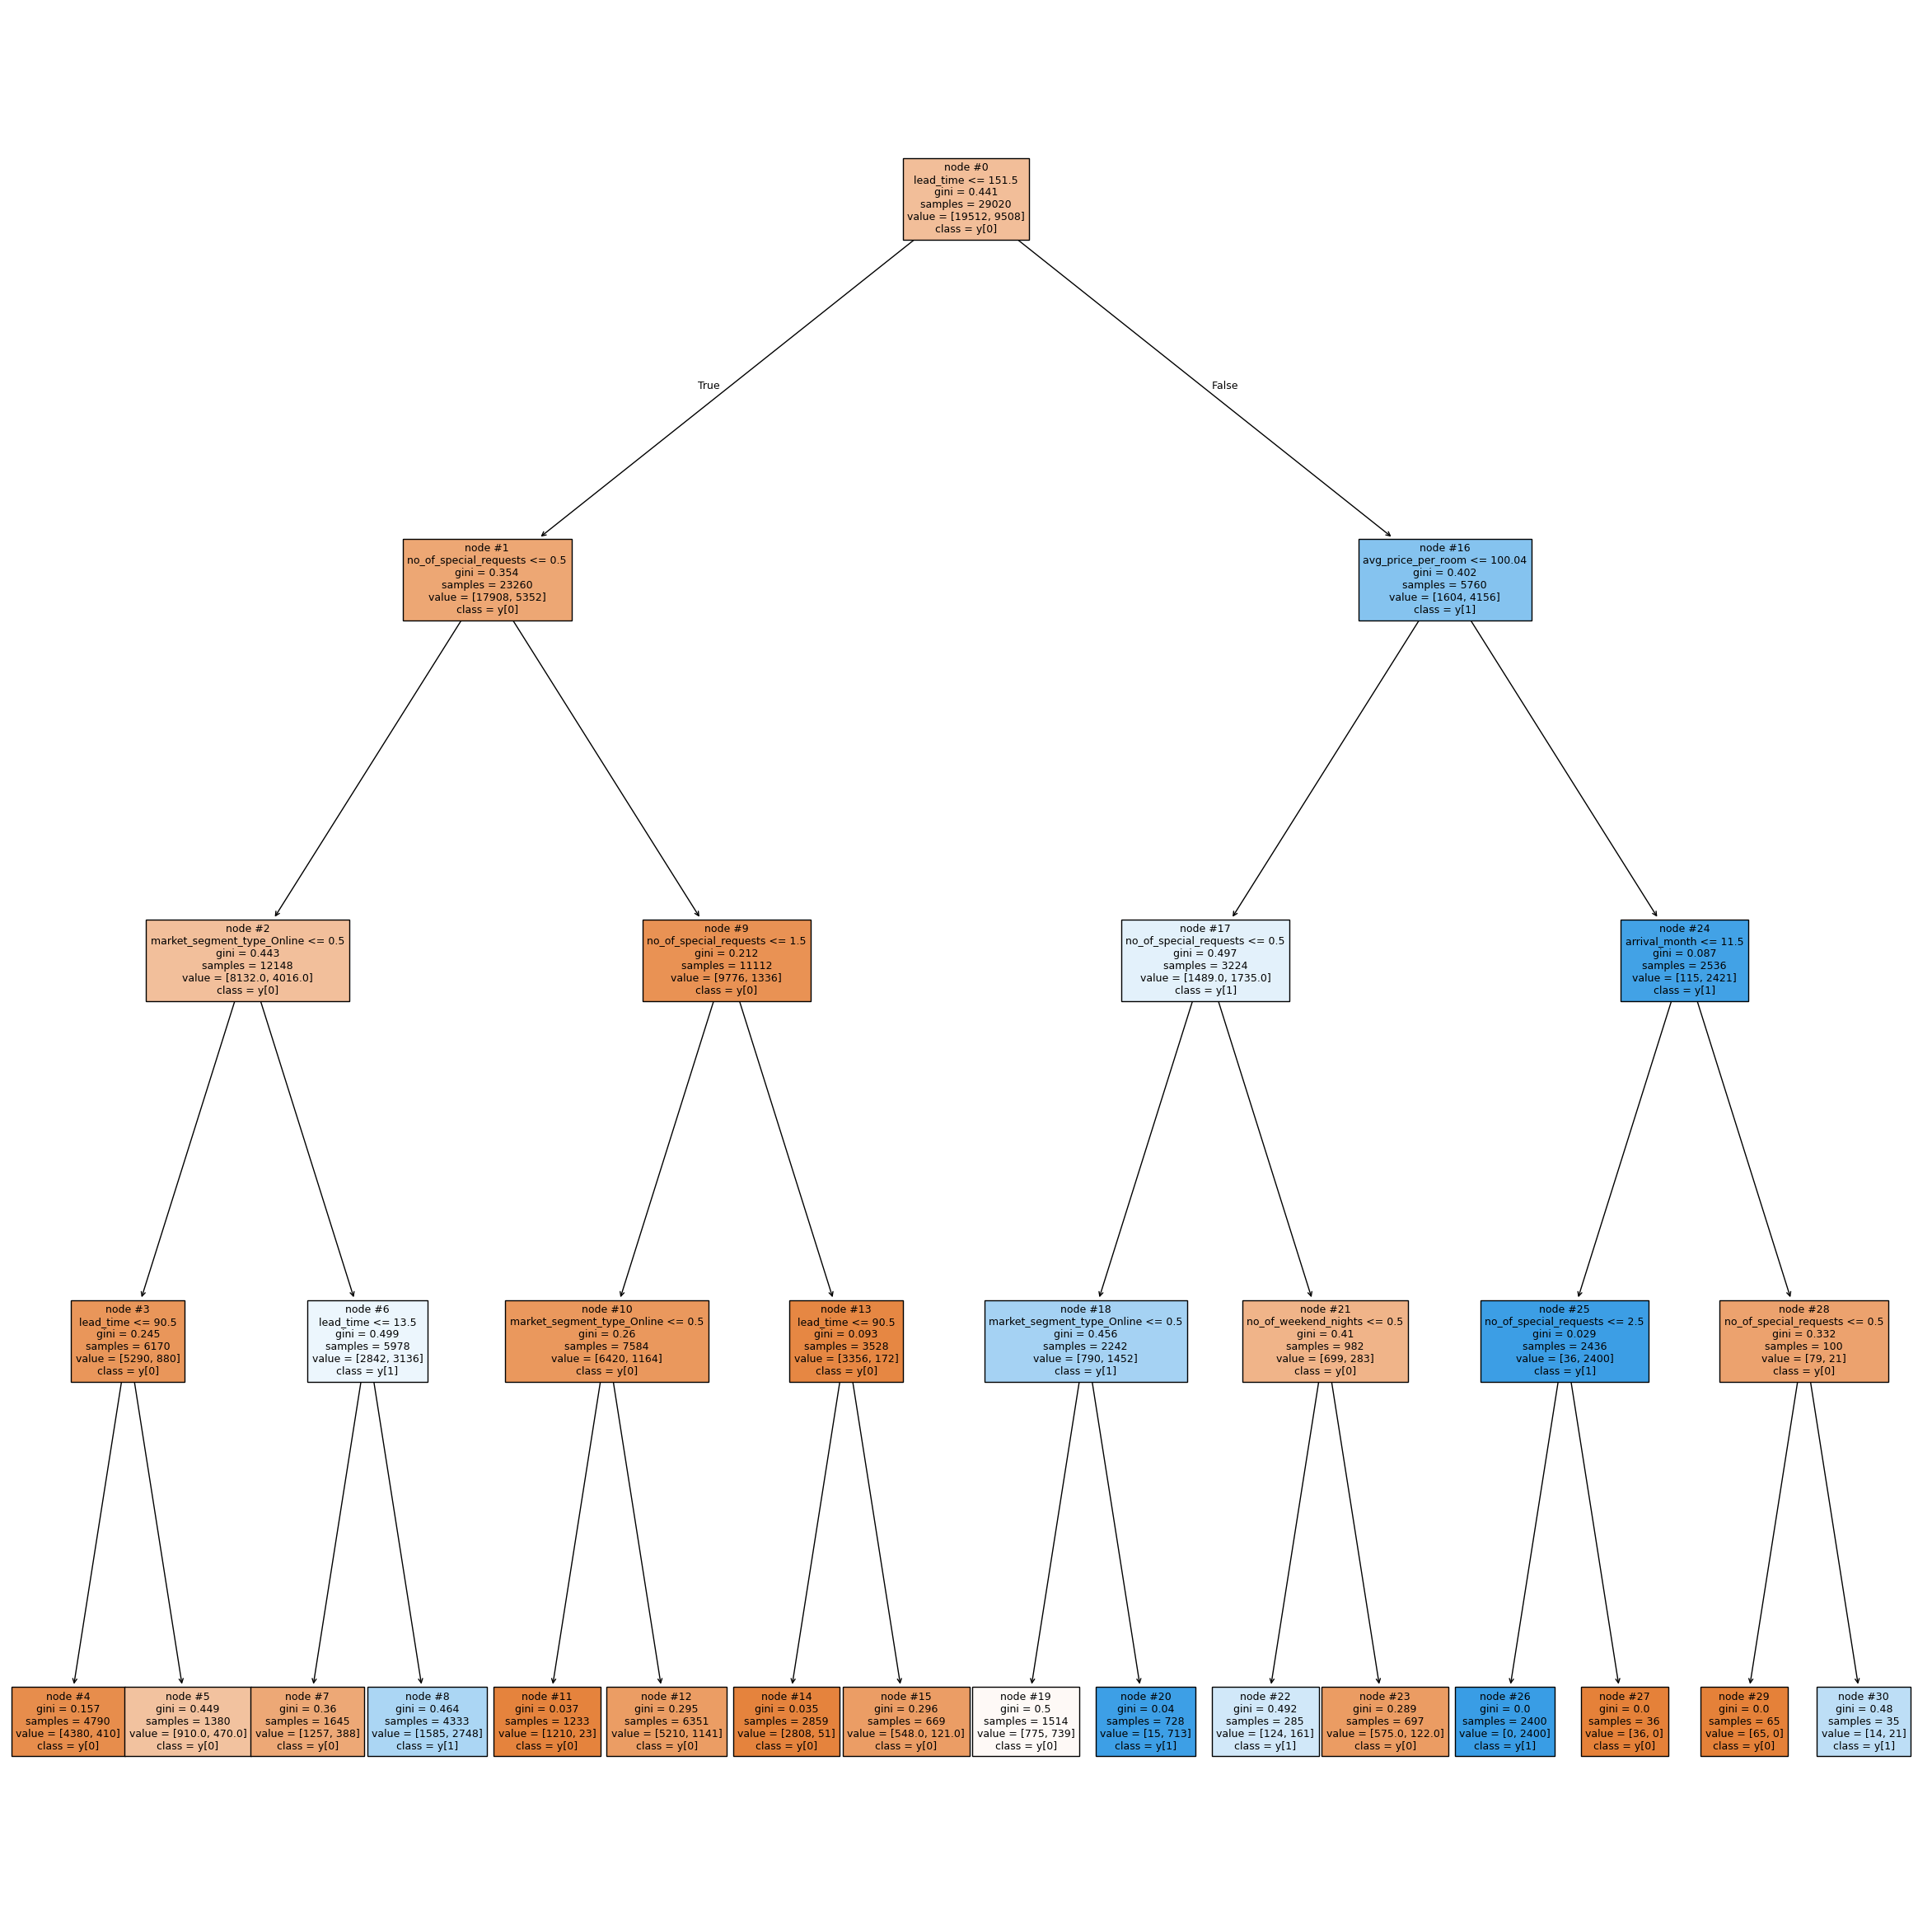

CPU times: user 1.26 s, sys: 205 ms, total: 1.46 s
Wall time: 1.79 s


In [64]:
%%time
plt.figure(figsize=(30, 30))
plot_tree(dt, feature_names=X_train.columns.to_list(), filled=True, fontsize=9, node_ids=True, class_names=True)
plt.show()

In [65]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification_sklearn(model, predictors, target, threshold=0.5):
    # predicting using the independent variables
    pred = model.predict_proba(predictors)[:,1] > threshold

    acc = accuracy_score(target, pred)  # to compute Accuracy
    b_acc = balanced_accuracy_score(target, pred) # balanced accuracy: average of recall obtained on each class
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score
    auc = roc_auc_score(target, model.predict_proba(predictors)[:,1])

    # creating a dataframe of metrics
    df_perf = pd.DataFrame({"Accuracy": acc, "Balanced Accuracy": b_acc,
                            "Recall": recall, "Precision": precision,
                            "F1": f1, "AUC": auc}, index=[0],)
    return df_perf

In [66]:

# model performance on the training dataset
print('Evaluation metrics on the training dataset')
dt_train_perf = model_performance_classification_sklearn(dt, X_train, y_train, threshold=0.5)
display(dt_train_perf)

# model performance on the testing dataset
print('Evaluation metrics on the testing dataset')
dt_test_perf = model_performance_classification_sklearn(dt, X_test, y_test, threshold=0.5)
display(dt_test_perf)

Evaluation metrics on the training dataset


,Accuracy,Balanced Accuracy,Recall,Precision,F1,AUC
0,0.82071,0.773248,0.63557,0.776635,0.699057,0.867343


Evaluation metrics on the testing dataset


,Accuracy,Balanced Accuracy,Recall,Precision,F1,AUC
0,0.814335,0.766917,0.629365,0.762487,0.68956,0.861967


Values for evaluation metrics indicate that the model is a good fit since they are high enough for the model to be performing well, but not too high for it to be overfitting.
Also, the values are similar for training and testing datasets, and that is a good sign indicating that the performance of the model is consistent on both datasets.

### 3-2) Display the `Confusion Matrix` of your default decision tree on the test set, using `'Canceled'` as the `positive` class. (5 points)

In [67]:
from sklearn.metrics import confusion_matrix

y_pred = dt.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)


[[4412  466]
 [ 881 1496]]


### 3-3) Draw the `ROC Curve` of your default decision tree on the test set, using `'Canceled'` as the `positive` class. Report the AUC score. (5 points)

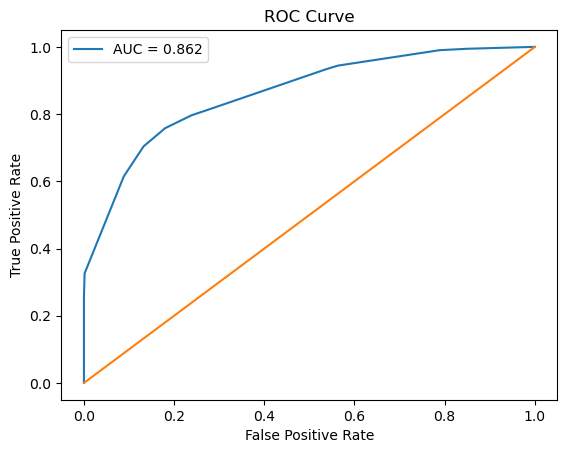

In [68]:
y_pred_proba = dt.predict_proba(X_test)[:, 1]

from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


AUC score = 0.862 (which is considered a good score)

### 4-1) Tune the hyperparameters for the decision tree and find the optimal set of hyperparamter. Use `GridSearchCV` technique. Use `F1 score` as your main scorer for the optimization. (10 points)

**Hint**: Use **`cv=5`** when doing cross validation.

In [69]:
cols_to_drop = [c for c in X_train.columns if c.startswith("Booking_ID_")]
X_train = X_train.drop(columns=cols_to_drop)
X_test  = X_test.drop(columns=cols_to_drop)


In [70]:
const_cols = [col for col in X_train.columns if X_train[col].nunique() == 1]
X_train = X_train.drop(columns=const_cols)
X_test = X_test.drop(columns=const_cols)


In [71]:
rare_cols = [col for col in X_train.columns if X_train[col].sum() < 5]
X_train = X_train.drop(columns=rare_cols)
X_test  = X_test.drop(columns=rare_cols)


In [72]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(f_classif, k=200)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)


In [73]:
%%time

# Choose the type of classifier. 
dt1 = DecisionTreeClassifier(random_state=42)

parameters = {
    "max_depth": [7, 8],               # keep both
    "min_samples_split": [10, 50],     # low vs high
    "min_samples_leaf": [10],          # stable value
    "max_features": ['sqrt'],          # best default for classification trees
    "max_leaf_nodes": [25, 50],        # keep both
    "class_weight": [{0:0.1, 1:0.9}]   # pick the more balanced one
}


# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.f1_score)

grid_obj_dt1 = GridSearchCV(dt1, parameters, scoring=acc_scorer, cv=5, n_jobs= 1, verbose = 2)

grid_obj_dt1 = grid_obj_dt1.fit(X_train, y_train)

# Print the best combination of parameters
grid_obj_dt1.best_params_

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END class_weight={0: 0.1, 1: 0.9}, max_depth=7, max_features=sqrt, max_leaf_nodes=25, min_samples_leaf=10, min_samples_split=10; total time=   0.0s
[CV] END class_weight={0: 0.1, 1: 0.9}, max_depth=7, max_features=sqrt, max_leaf_nodes=25, min_samples_leaf=10, min_samples_split=10; total time=   0.0s
[CV] END class_weight={0: 0.1, 1: 0.9}, max_depth=7, max_features=sqrt, max_leaf_nodes=25, min_samples_leaf=10, min_samples_split=10; total time=   0.0s
[CV] END class_weight={0: 0.1, 1: 0.9}, max_depth=7, max_features=sqrt, max_leaf_nodes=25, min_samples_leaf=10, min_samples_split=10; total time=   0.0s
[CV] END class_weight={0: 0.1, 1: 0.9}, max_depth=7, max_features=sqrt, max_leaf_nodes=25, min_samples_leaf=10, min_samples_split=10; total time=   0.0s
[CV] END class_weight={0: 0.1, 1: 0.9}, max_depth=7, max_features=sqrt, max_leaf_nodes=25, min_samples_leaf=10, min_samples_split=50; total time=   0.0s
[CV] END class_weight=

{'class_weight': {0: 0.1, 1: 0.9},
 'max_depth': 8,
 'max_features': 'sqrt',
 'max_leaf_nodes': 50,
 'min_samples_leaf': 10,
 'min_samples_split': 50}

### 4-2) Train a `new` decision tree `with the optimal hyperparameter` that you found above and evaluate the performance of the model on the training and the testing dataset. (5 points)

**Hint**: To ensure the results are reproducible, use **`random_state=42`** when training

In [74]:
# use the best combination of parameters to train the model
dt1_tuned = DecisionTreeClassifier(
            min_samples_split = grid_obj_dt1.best_params_['min_samples_split'],
            min_samples_leaf = grid_obj_dt1.best_params_['min_samples_leaf'],
            max_leaf_nodes = grid_obj_dt1.best_params_['max_leaf_nodes'],
            max_features = grid_obj_dt1.best_params_['max_features'],
            max_depth = grid_obj_dt1.best_params_['max_depth'],
            class_weight = grid_obj_dt1.best_params_['class_weight'],
            random_state = 42
)

# Fit the best model to the data.
dt1_tuned.fit(X_train, y_train)

DecisionTreeClassifier(class_weight={0: 0.1, 1: 0.9}, max_depth=8,
                       max_features='sqrt', max_leaf_nodes=50,
                       min_samples_leaf=10, min_samples_split=50,
                       random_state=42)

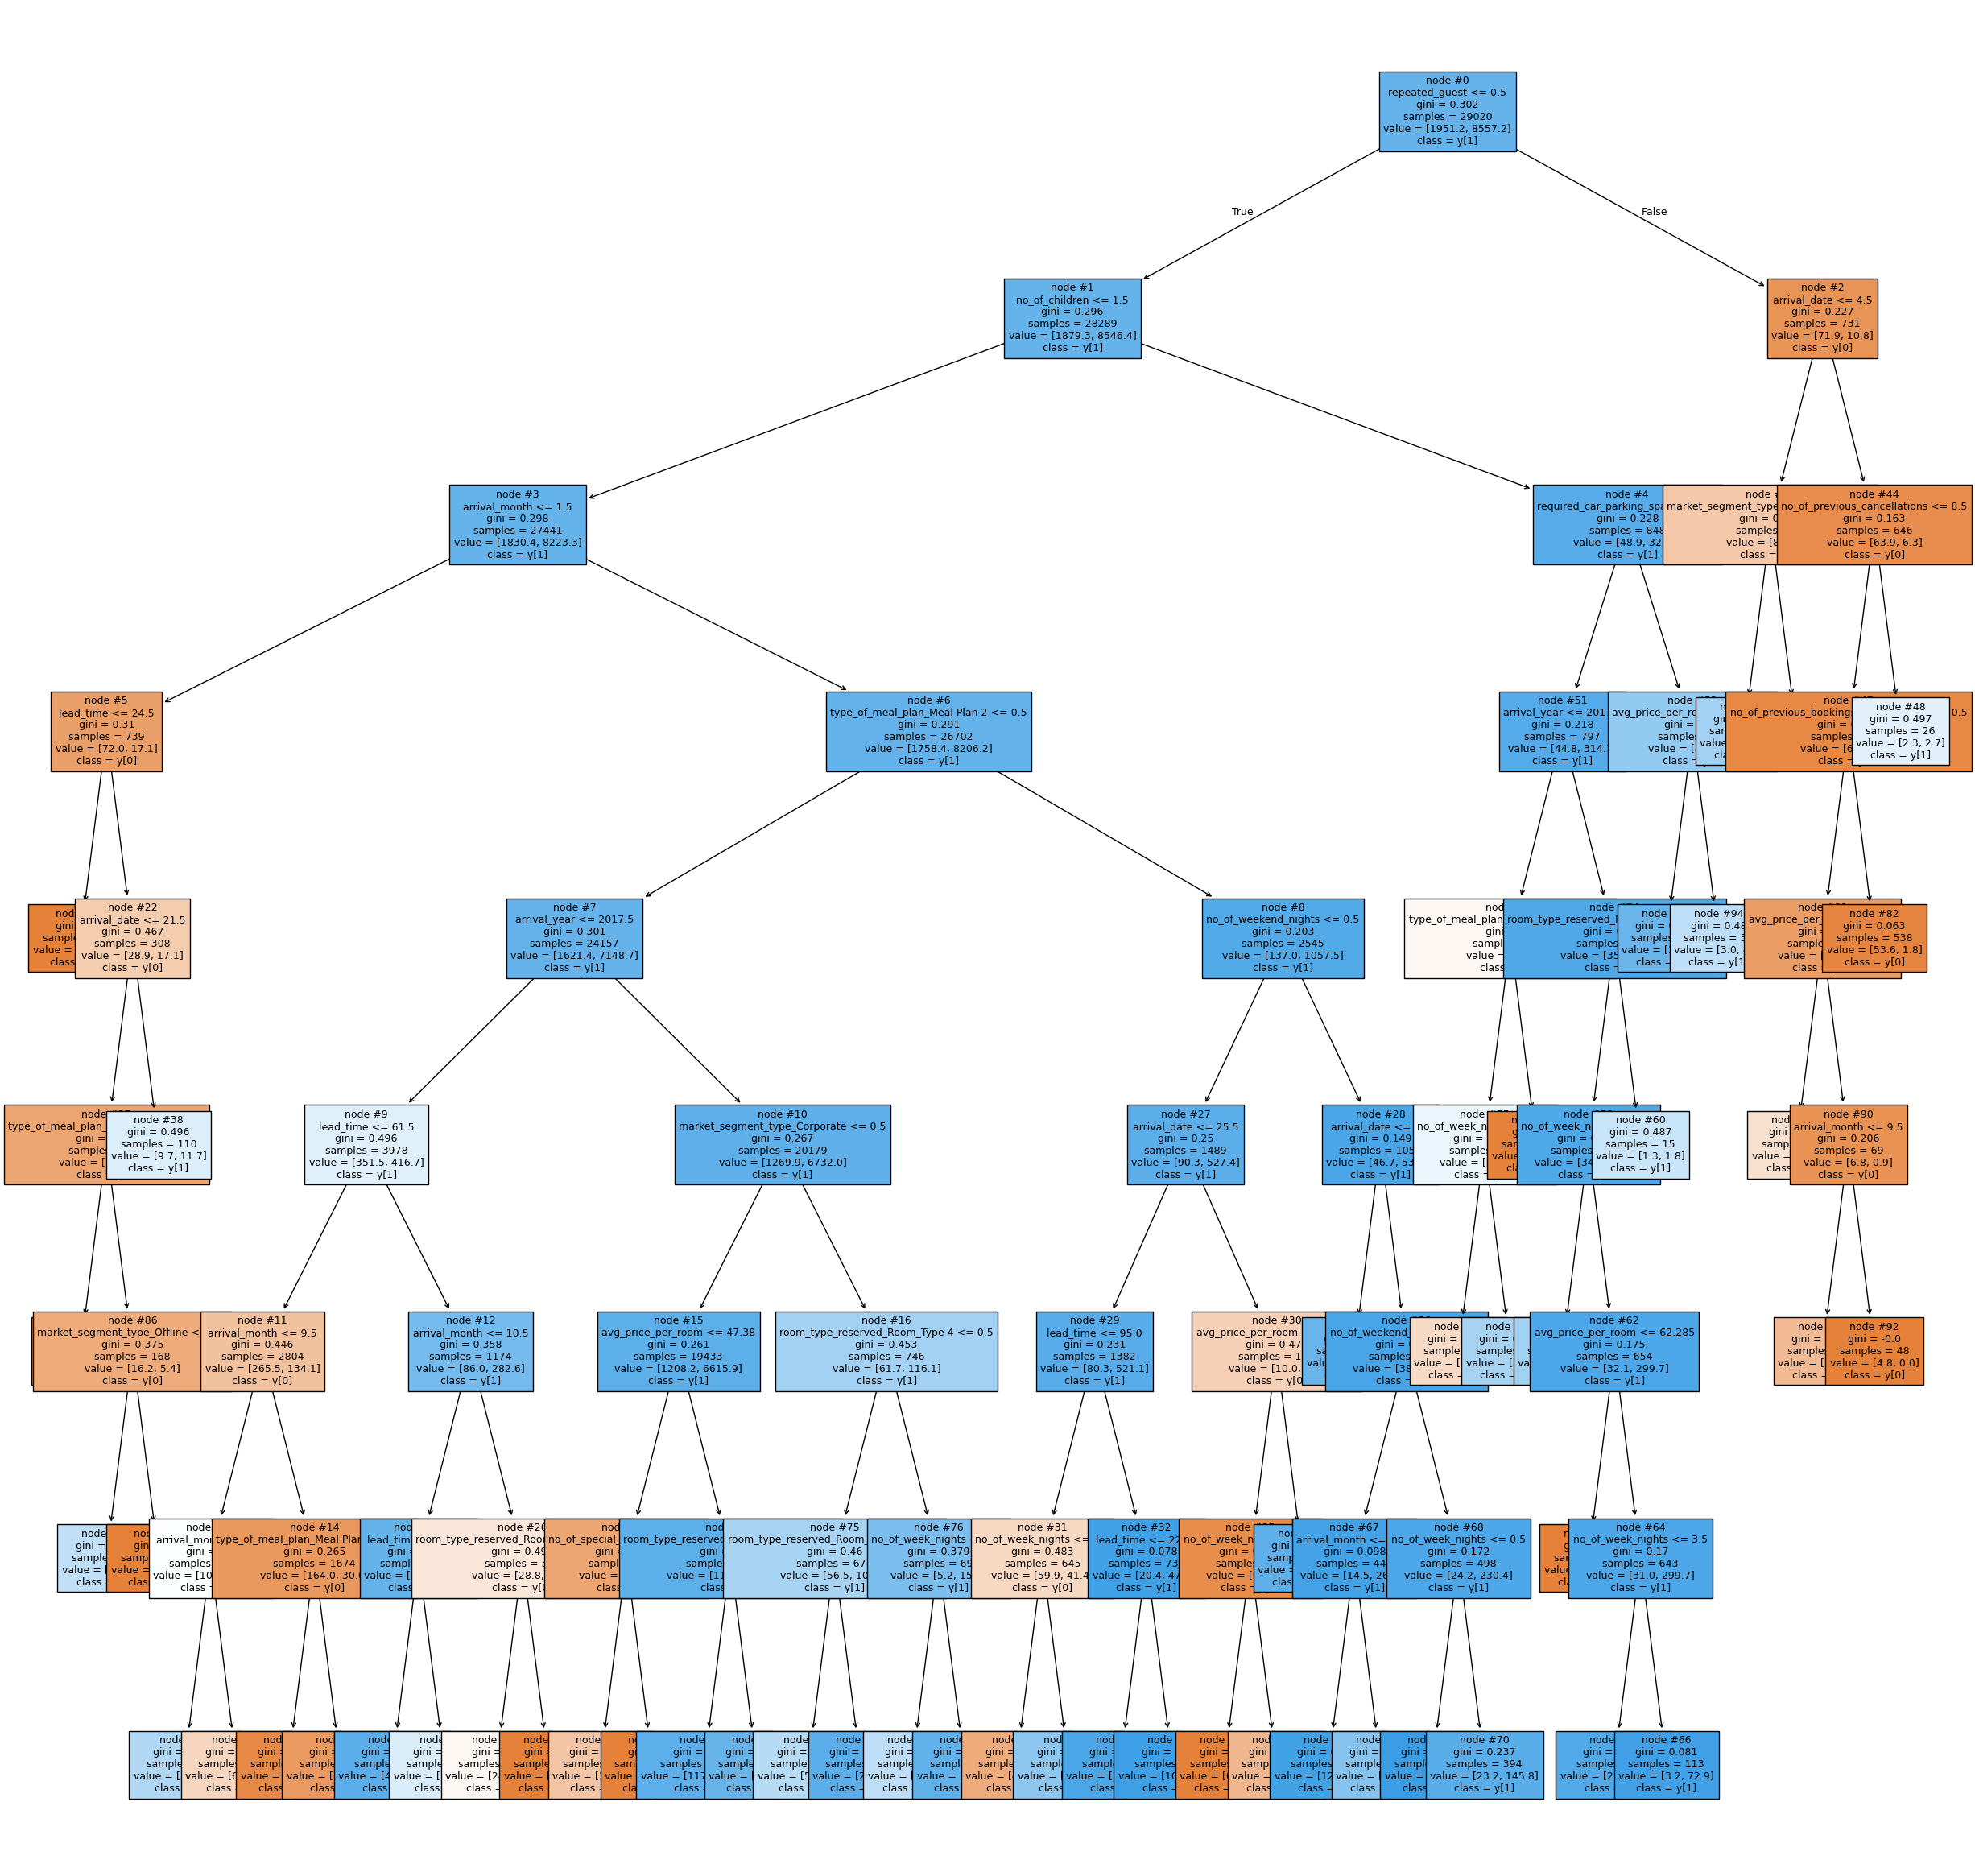

CPU times: user 2.94 s, sys: 175 ms, total: 3.11 s
Wall time: 3.14 s


In [75]:
%%time
plt.figure(figsize=(30, 30))
plot_tree(dt1_tuned, feature_names=X_train.columns.to_list(), filled=True, fontsize=9, node_ids=True, class_names=True)
plt.show()

In [76]:
# model performance on the training dataset
print('Evaluation metrics on the training dataset')
dt1_tuned_train_perf = model_performance_classification_sklearn(dt1_tuned, X_train, y_train, threshold=0.5)
display(dt1_tuned_train_perf)

# model performance on the testing dataset
print('Evaluation metrics on the testing dataset')
dt1_tuned_test_perf = model_performance_classification_sklearn(dt1_tuned, X_test, y_test, threshold=0.5)
display(dt1_tuned_test_perf)

Evaluation metrics on the training dataset


,Accuracy,Balanced Accuracy,Recall,Precision,F1,AUC
0,0.485424,0.613456,0.984855,0.387695,0.556371,0.672943


Evaluation metrics on the testing dataset


,Accuracy,Balanced Accuracy,Recall,Precision,F1,AUC
0,0.485045,0.613066,0.984434,0.387481,0.556084,0.669052


Accuracy, precision and F1 seem to be low. Recall is high, and AUC value is fair. But, since our focus is on the f1 score, we will not consider this to be a good model.
However, there does seem to be a good balance between the training and testing dataset values.

### 5-1) Tune the hyperparameters for the decision tree and find the optimal set of hyperparamter. Use `RandomizedSearchCV` technique. Use `F1 score` as your main scorer for the optimization. (10 points)

**Hint**: To ensure the results are reproducible, use **`random_state=42`** when doing randomized search; use **`cv=5`** when doing cross validation.

In [77]:
%%time

# Choose the type of classifier. 
dt2 = DecisionTreeClassifier(random_state=42)

# Grid of parameters to choose from
parameters = {
    # The maximum depth of the tree. If None, then nodes 
    # are expanded until all leaves are pure or until all leaves 
    # contain less than min_samples_split samples.
    "max_depth": np.arange(3, 9),
    # The minimum number of samples required to split an internal node
    "min_samples_split": [5, 10, 30, 50, 70],
    # The minimum number of samples required to be at a leaf node
    "min_samples_leaf": [5, 10, 15, 20],
    # The number of features to consider when looking for the best split
    "max_features": ['auto', 'sqrt', 'log2'],
    # Grow a tree with max_leaf_nodes in best-first fashion
    "max_leaf_nodes": [10, 25, 50, 100],
    # Weights associated with classes
    "class_weight": [{0:0.1, 1:0.9}, {0:0.05, 1:0.95}, {0:0.2, 1:0.8}]
    
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.f1_score)

# Run the randomized search
rand_obj_dt2 = RandomizedSearchCV(dt2, parameters, n_iter=10, scoring=acc_scorer, cv=5, n_jobs= 1, verbose = 2)
# verbose = 2 tells about the number of fits, which can give an idea of how long will the model take in tuning
# n_jobs = 1 to avoid crashing my machine

rand_obj_dt2 = rand_obj_dt2.fit(X_train, y_train)

# Print the best combination of parameters
rand_obj_dt2.best_params_

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END class_weight={0: 0.1, 1: 0.9}, max_depth=3, max_features=sqrt, max_leaf_nodes=100, min_samples_leaf=15, min_samples_split=70; total time=   0.0s
[CV] END class_weight={0: 0.1, 1: 0.9}, max_depth=3, max_features=sqrt, max_leaf_nodes=100, min_samples_leaf=15, min_samples_split=70; total time=   0.0s
[CV] END class_weight={0: 0.1, 1: 0.9}, max_depth=3, max_features=sqrt, max_leaf_nodes=100, min_samples_leaf=15, min_samples_split=70; total time=   0.0s
[CV] END class_weight={0: 0.1, 1: 0.9}, max_depth=3, max_features=sqrt, max_leaf_nodes=100, min_samples_leaf=15, min_samples_split=70; total time=   0.0s
[CV] END class_weight={0: 0.1, 1: 0.9}, max_depth=3, max_features=sqrt, max_leaf_nodes=100, min_samples_leaf=15, min_samples_split=70; total time=   0.0s
[CV] END class_weight={0: 0.1, 1: 0.9}, max_depth=6, max_features=sqrt, max_leaf_nodes=100, min_samples_leaf=5, min_samples_split=70; total time=   0.0s
[CV] END class_w

{'min_samples_split': 50,
 'min_samples_leaf': 10,
 'max_leaf_nodes': 25,
 'max_features': 'sqrt',
 'max_depth': np.int64(5),
 'class_weight': {0: 0.2, 1: 0.8}}

In [78]:
# # use the best combination of parameters to train the model
dt2_tuned = DecisionTreeClassifier(
            min_samples_split = rand_obj_dt2.best_params_['min_samples_split'],
            min_samples_leaf = rand_obj_dt2.best_params_['min_samples_leaf'],
            max_leaf_nodes = rand_obj_dt2.best_params_['max_leaf_nodes'],
            max_features = rand_obj_dt2.best_params_['max_features'],
            max_depth = rand_obj_dt2.best_params_['max_depth'],
            class_weight = rand_obj_dt2.best_params_['class_weight'],
            random_state = 42
)

# Fit the best model to the data.
dt2_tuned.fit(X_train, y_train)

DecisionTreeClassifier(class_weight={0: 0.2, 1: 0.8}, max_depth=np.int64(5),
                       max_features='sqrt', max_leaf_nodes=25,
                       min_samples_leaf=10, min_samples_split=50,
                       random_state=42)

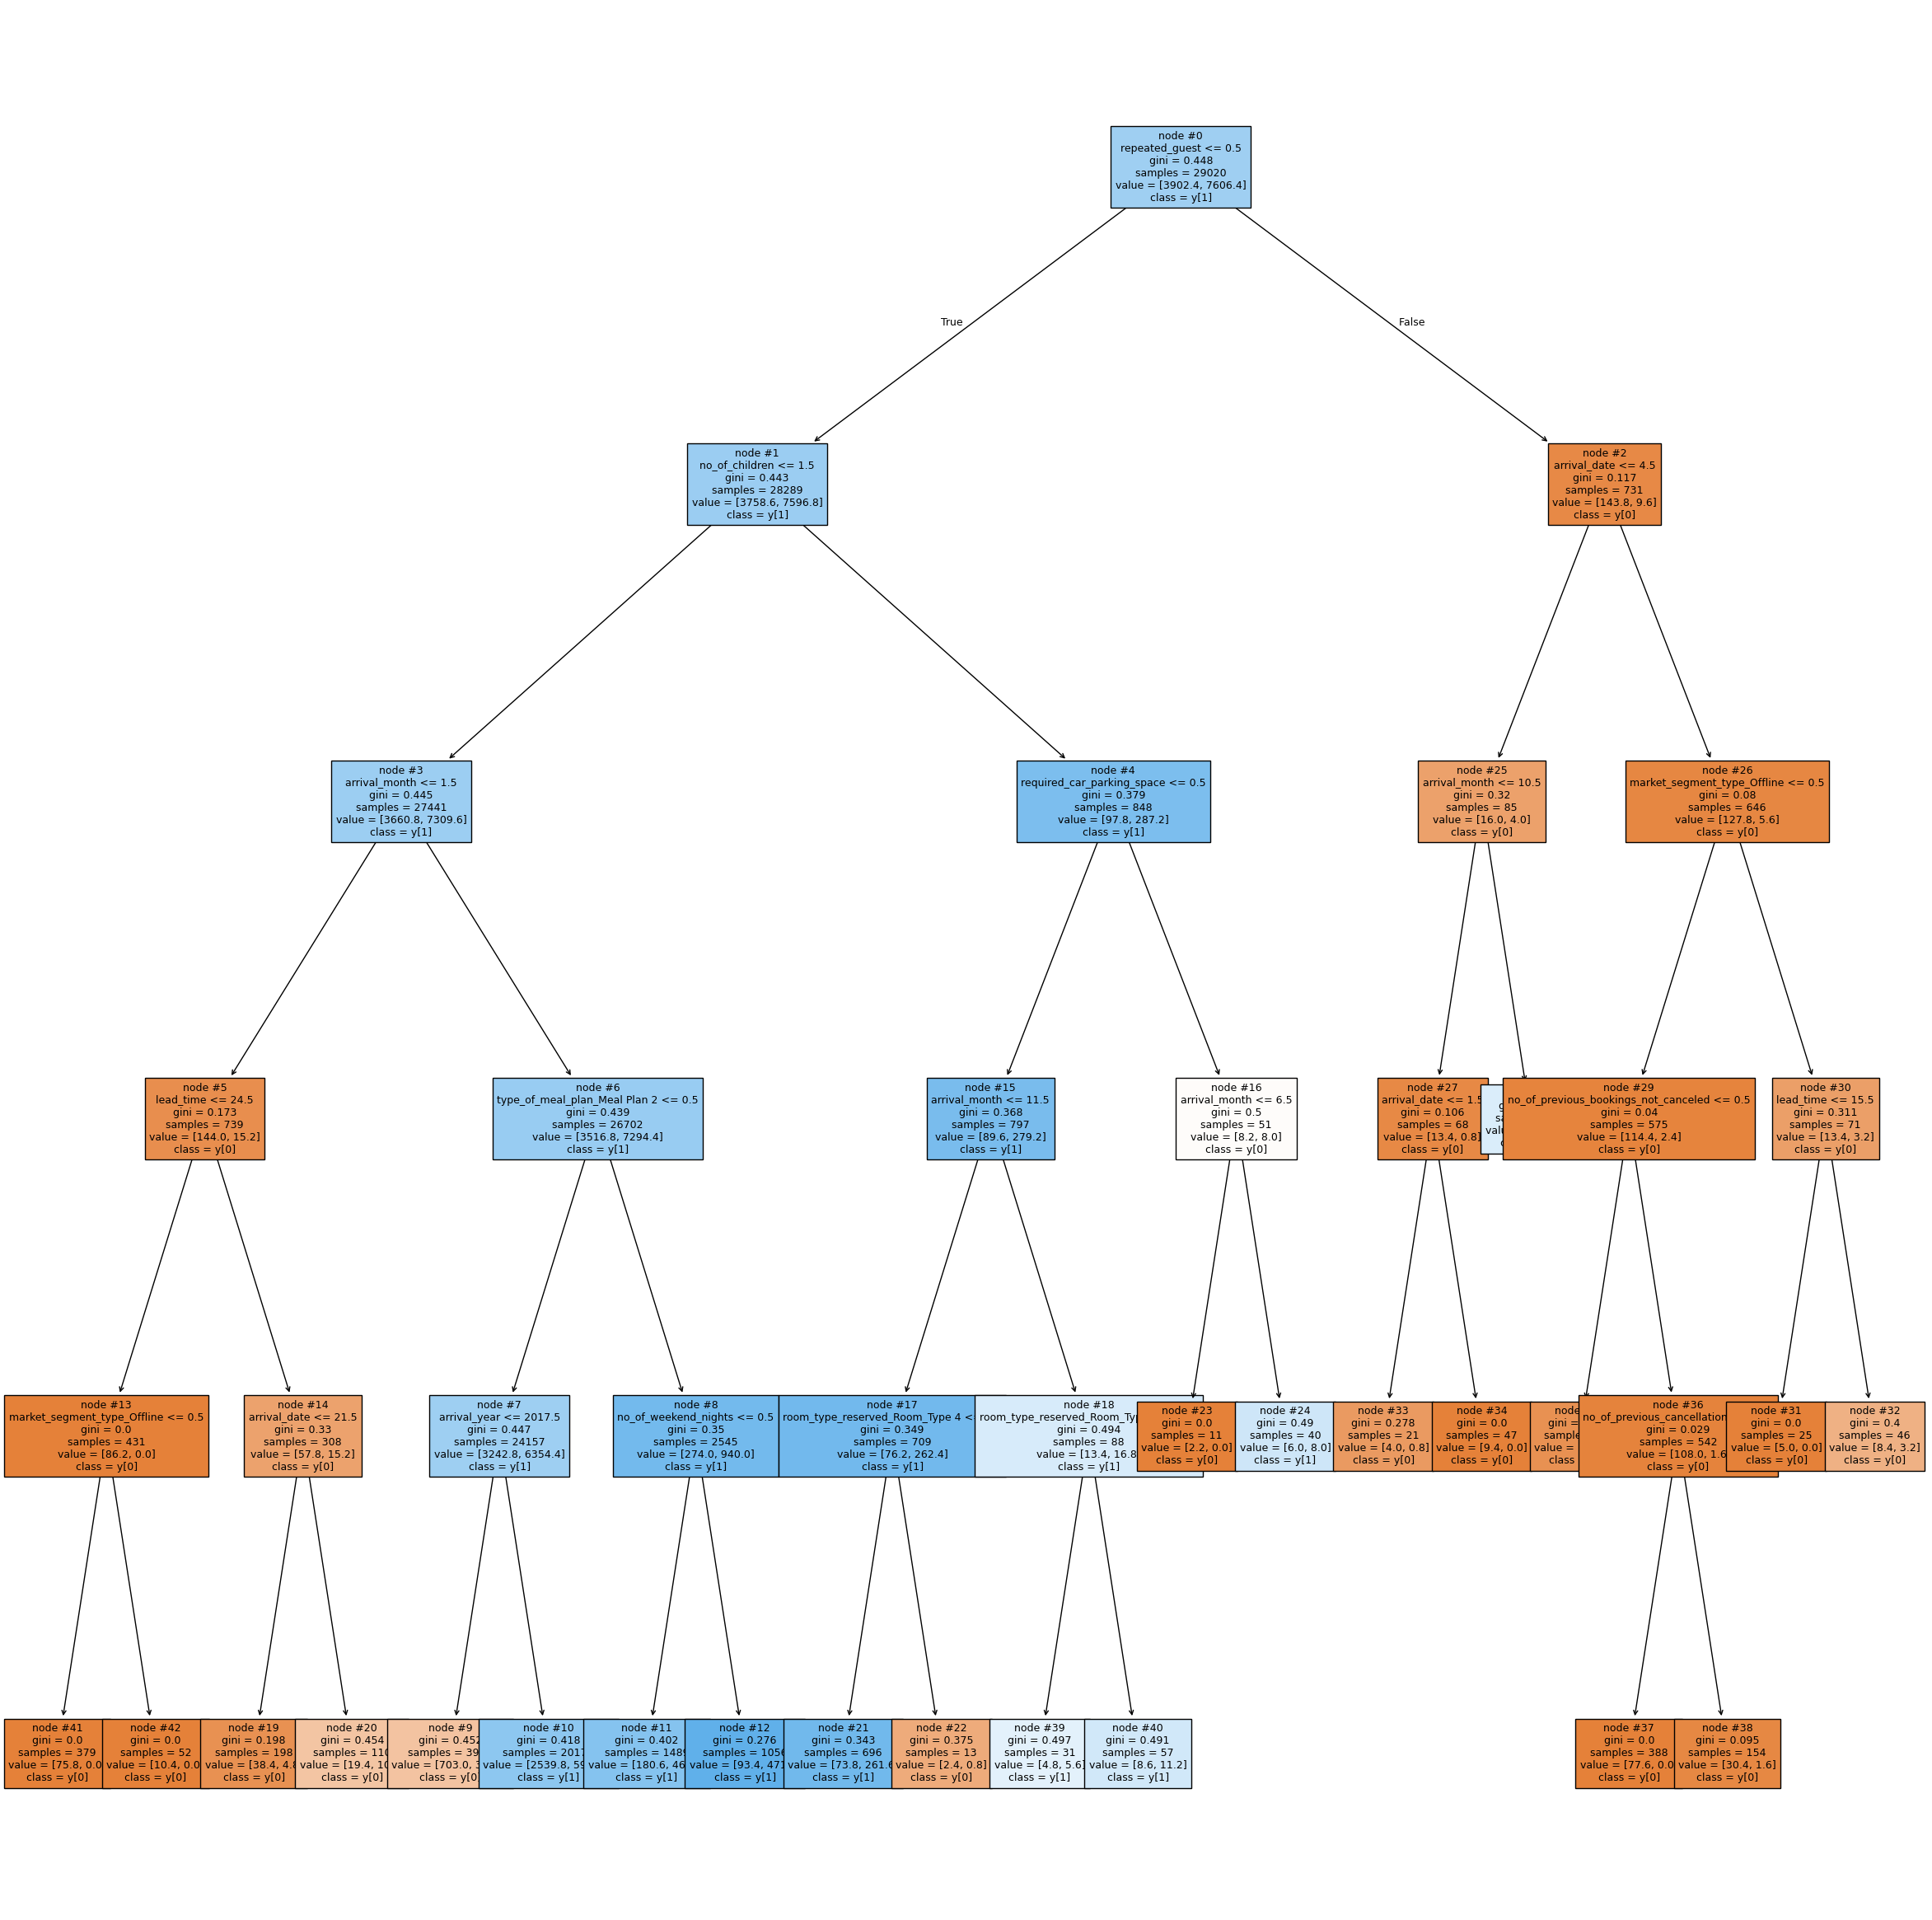

CPU times: user 1.51 s, sys: 95.5 ms, total: 1.61 s
Wall time: 1.72 s


In [79]:
%%time
plt.figure(figsize=(30, 30))
plot_tree(dt2_tuned, feature_names=X_train.columns.to_list(), filled=True, fontsize=9, node_ids=True, class_names=True)
plt.show()

In [80]:
# model performance on the training dataset
print('Evaluation metrics on the training dataset')
dt2_tuned_train_perf = model_performance_classification_sklearn(dt2_tuned, X_train, y_train, threshold=0.5)
display(dt2_tuned_train_perf)

# model performance on the testing dataset
print('Evaluation metrics on the validation dataset')
dt2_tuned_test_perf = model_performance_classification_sklearn(dt2_tuned, X_test, y_test, threshold=0.5)
display(dt2_tuned_test_perf)

Evaluation metrics on the training dataset


,Accuracy,Balanced Accuracy,Recall,Precision,F1,AUC
0,0.481771,0.601383,0.948359,0.382644,0.545279,0.62175


Evaluation metrics on the validation dataset


,Accuracy,Balanced Accuracy,Recall,Precision,F1,AUC
0,0.476085,0.598962,0.955406,0.380657,0.544408,0.622074


Even though recall is very high, F1 score is considered low. Precision is very low. values are matching between training and testing. But, since our focus is on F1, we will not consider this a good model.

### 5-2) Train a `new` decision tree `with the optimal hyperparameter` that you found above and evaluate the performance of the model on the training and the testing dataset. (5 points)

**Hint**: To ensure the results are reproducible, use **`random_state=42`** when training

(merged with 5-1)

## Random Forest Train & Tuning

### 6) Build a `default` `random forest` model. Evaluate the performance of your default random forest model on the training and the test data set. State your observation on whether the model is overfit/underfit. (5 points)

**Hint**: To ensure the results are reproducible, use **`random_state=42`** when training

In [81]:
# model without hyperparameter tuning
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [82]:
# model performance on the training dataset
print('Evaluation metrics on the training dataset')
rf_train_perf = model_performance_classification_sklearn(rf, X_train, y_train, threshold=0.5)
display(rf_train_perf)

# model performance on the testing dataset
print('Evaluation metrics on the testing dataset')
rf_test_perf = model_performance_classification_sklearn(rf, X_test, y_test, threshold=0.5)
display(rf_test_perf)

Evaluation metrics on the training dataset


,Accuracy,Balanced Accuracy,Recall,Precision,F1,AUC
0,0.994452,0.992531,0.986958,0.996073,0.991495,0.999419


Evaluation metrics on the testing dataset


,Accuracy,Balanced Accuracy,Recall,Precision,F1,AUC
0,0.900069,0.87791,0.813631,0.872744,0.842151,0.952704


### 7-1) Tune the hyperparameters for the random forest and find the optimal set of hyperparamters. Use `GridSearchCV` technique. Use `F1 score` as your main scorer for the optimization. (10 points)

**Hint**: Use **`cv=5`** when doing cross validation.

In [83]:
%%time

# Choose the type of classifier. 
rf1 = RandomForestClassifier(random_state=42)

# Grid of parameters to choose from
parameters = {
    "n_estimators": [20, 40],       # small but meaningful
    "min_samples_leaf": [5, 10],    # typical values
    "max_depth": [4, 6],            # shallow but useful
    "class_weight": ['balanced'],   # required for imbalance
    "max_features": ['sqrt'],       # optimal for RF
}


# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.f1_score)

# Run the randomized search
rand_obj_rf1 = GridSearchCV(rf1, parameters, scoring=acc_scorer, cv=5, n_jobs= 1, verbose = 2)
# verbose = 2 tells about the number of fits, which can give an idea of how long will the model take in tuning
# n_jobs = 1 so that my computer won't crash

rand_obj_rf1 = rand_obj_rf1.fit(X_train, y_train)

# Print the best combination of parameters
rand_obj_rf1.best_params_

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END class_weight=balanced, max_depth=4, max_features=sqrt, min_samples_leaf=5, n_estimators=20; total time=   0.2s
[CV] END class_weight=balanced, max_depth=4, max_features=sqrt, min_samples_leaf=5, n_estimators=20; total time=   0.2s
[CV] END class_weight=balanced, max_depth=4, max_features=sqrt, min_samples_leaf=5, n_estimators=20; total time=   0.2s
[CV] END class_weight=balanced, max_depth=4, max_features=sqrt, min_samples_leaf=5, n_estimators=20; total time=   0.2s
[CV] END class_weight=balanced, max_depth=4, max_features=sqrt, min_samples_leaf=5, n_estimators=20; total time=   0.2s
[CV] END class_weight=balanced, max_depth=4, max_features=sqrt, min_samples_leaf=5, n_estimators=40; total time=   0.4s
[CV] END class_weight=balanced, max_depth=4, max_features=sqrt, min_samples_leaf=5, n_estimators=40; total time=   0.4s
[CV] END class_weight=balanced, max_depth=4, max_features=sqrt, min_samples_leaf=5, n_estimators=40;

{'class_weight': 'balanced',
 'max_depth': 6,
 'max_features': 'sqrt',
 'min_samples_leaf': 5,
 'n_estimators': 40}

In [84]:

# use the best combination of parameters to train the model
rf1_tuned = DecisionTreeClassifier(
            min_samples_split = grid_obj_dt1.best_params_['min_samples_split'],
            min_samples_leaf = grid_obj_dt1.best_params_['min_samples_leaf'],
            max_leaf_nodes = grid_obj_dt1.best_params_['max_leaf_nodes'],
            max_features = grid_obj_dt1.best_params_['max_features'],
            max_depth = grid_obj_dt1.best_params_['max_depth'],
            class_weight = grid_obj_dt1.best_params_['class_weight'],
            random_state = 42
)

# Fit the best model to the data.
rf1_tuned.fit(X_train, y_train)

DecisionTreeClassifier(class_weight={0: 0.1, 1: 0.9}, max_depth=8,
                       max_features='sqrt', max_leaf_nodes=50,
                       min_samples_leaf=10, min_samples_split=50,
                       random_state=42)

In [85]:
# model performance on the training dataset
print('Evaluation metrics on the training dataset')
rf1_tuned_train_perf = model_performance_classification_sklearn(rf1_tuned, X_train, y_train, threshold=0.5)
display(rf1_tuned_train_perf)

# model performance on the testing dataset
print('Evaluation metrics on the testing dataset')
rf1_tuned_test_perf = model_performance_classification_sklearn(rf1_tuned, X_test, y_test, threshold=0.5)
display(rf1_tuned_test_perf)

Evaluation metrics on the training dataset


,Accuracy,Balanced Accuracy,Recall,Precision,F1,AUC
0,0.485424,0.613456,0.984855,0.387695,0.556371,0.672943


Evaluation metrics on the testing dataset


,Accuracy,Balanced Accuracy,Recall,Precision,F1,AUC
0,0.485045,0.613066,0.984434,0.387481,0.556084,0.669052


Values are matching for testing and training datasets, and even though recall is very high, f1 is considered low. Precision and accuracy are very low. Since our focus is on f1, this is not a good model.

### 7-2) Train a `new` random forest `with the optimal hyperparameter` that you found above and evaluate the performance of the model on the training and the testing dataset. (5 points)

**Hint**: To ensure the results are reproducible, use **`random_state=42`** when training

(merged with 7-1)

### 8) Compare all the models and decide which model is the most appropriate one based on the `F1 score` metric. (10 points)

It seems like our default decision tree model (1st model) is performing best, since it has the 2nd highest F1 score. The absolute highest F1 score belongs to Decision Tree based on RandomizedSearchCV, but that model is overfit, so we will not select it. All other models have lower F1 scores.

### 9) Visualize the tree structure of your best model. (5 points)
- If your best model is a single Decision Tree, plot the entire tree. 

- If your best model is a Random Forest, select any one tree from the forest and plot it.  

**Hint**: 
- For Random Forest, you can use `estimator.estimators_[0]` to access the first tree and use sklearn.`tree.plot_tree()` for visualization.

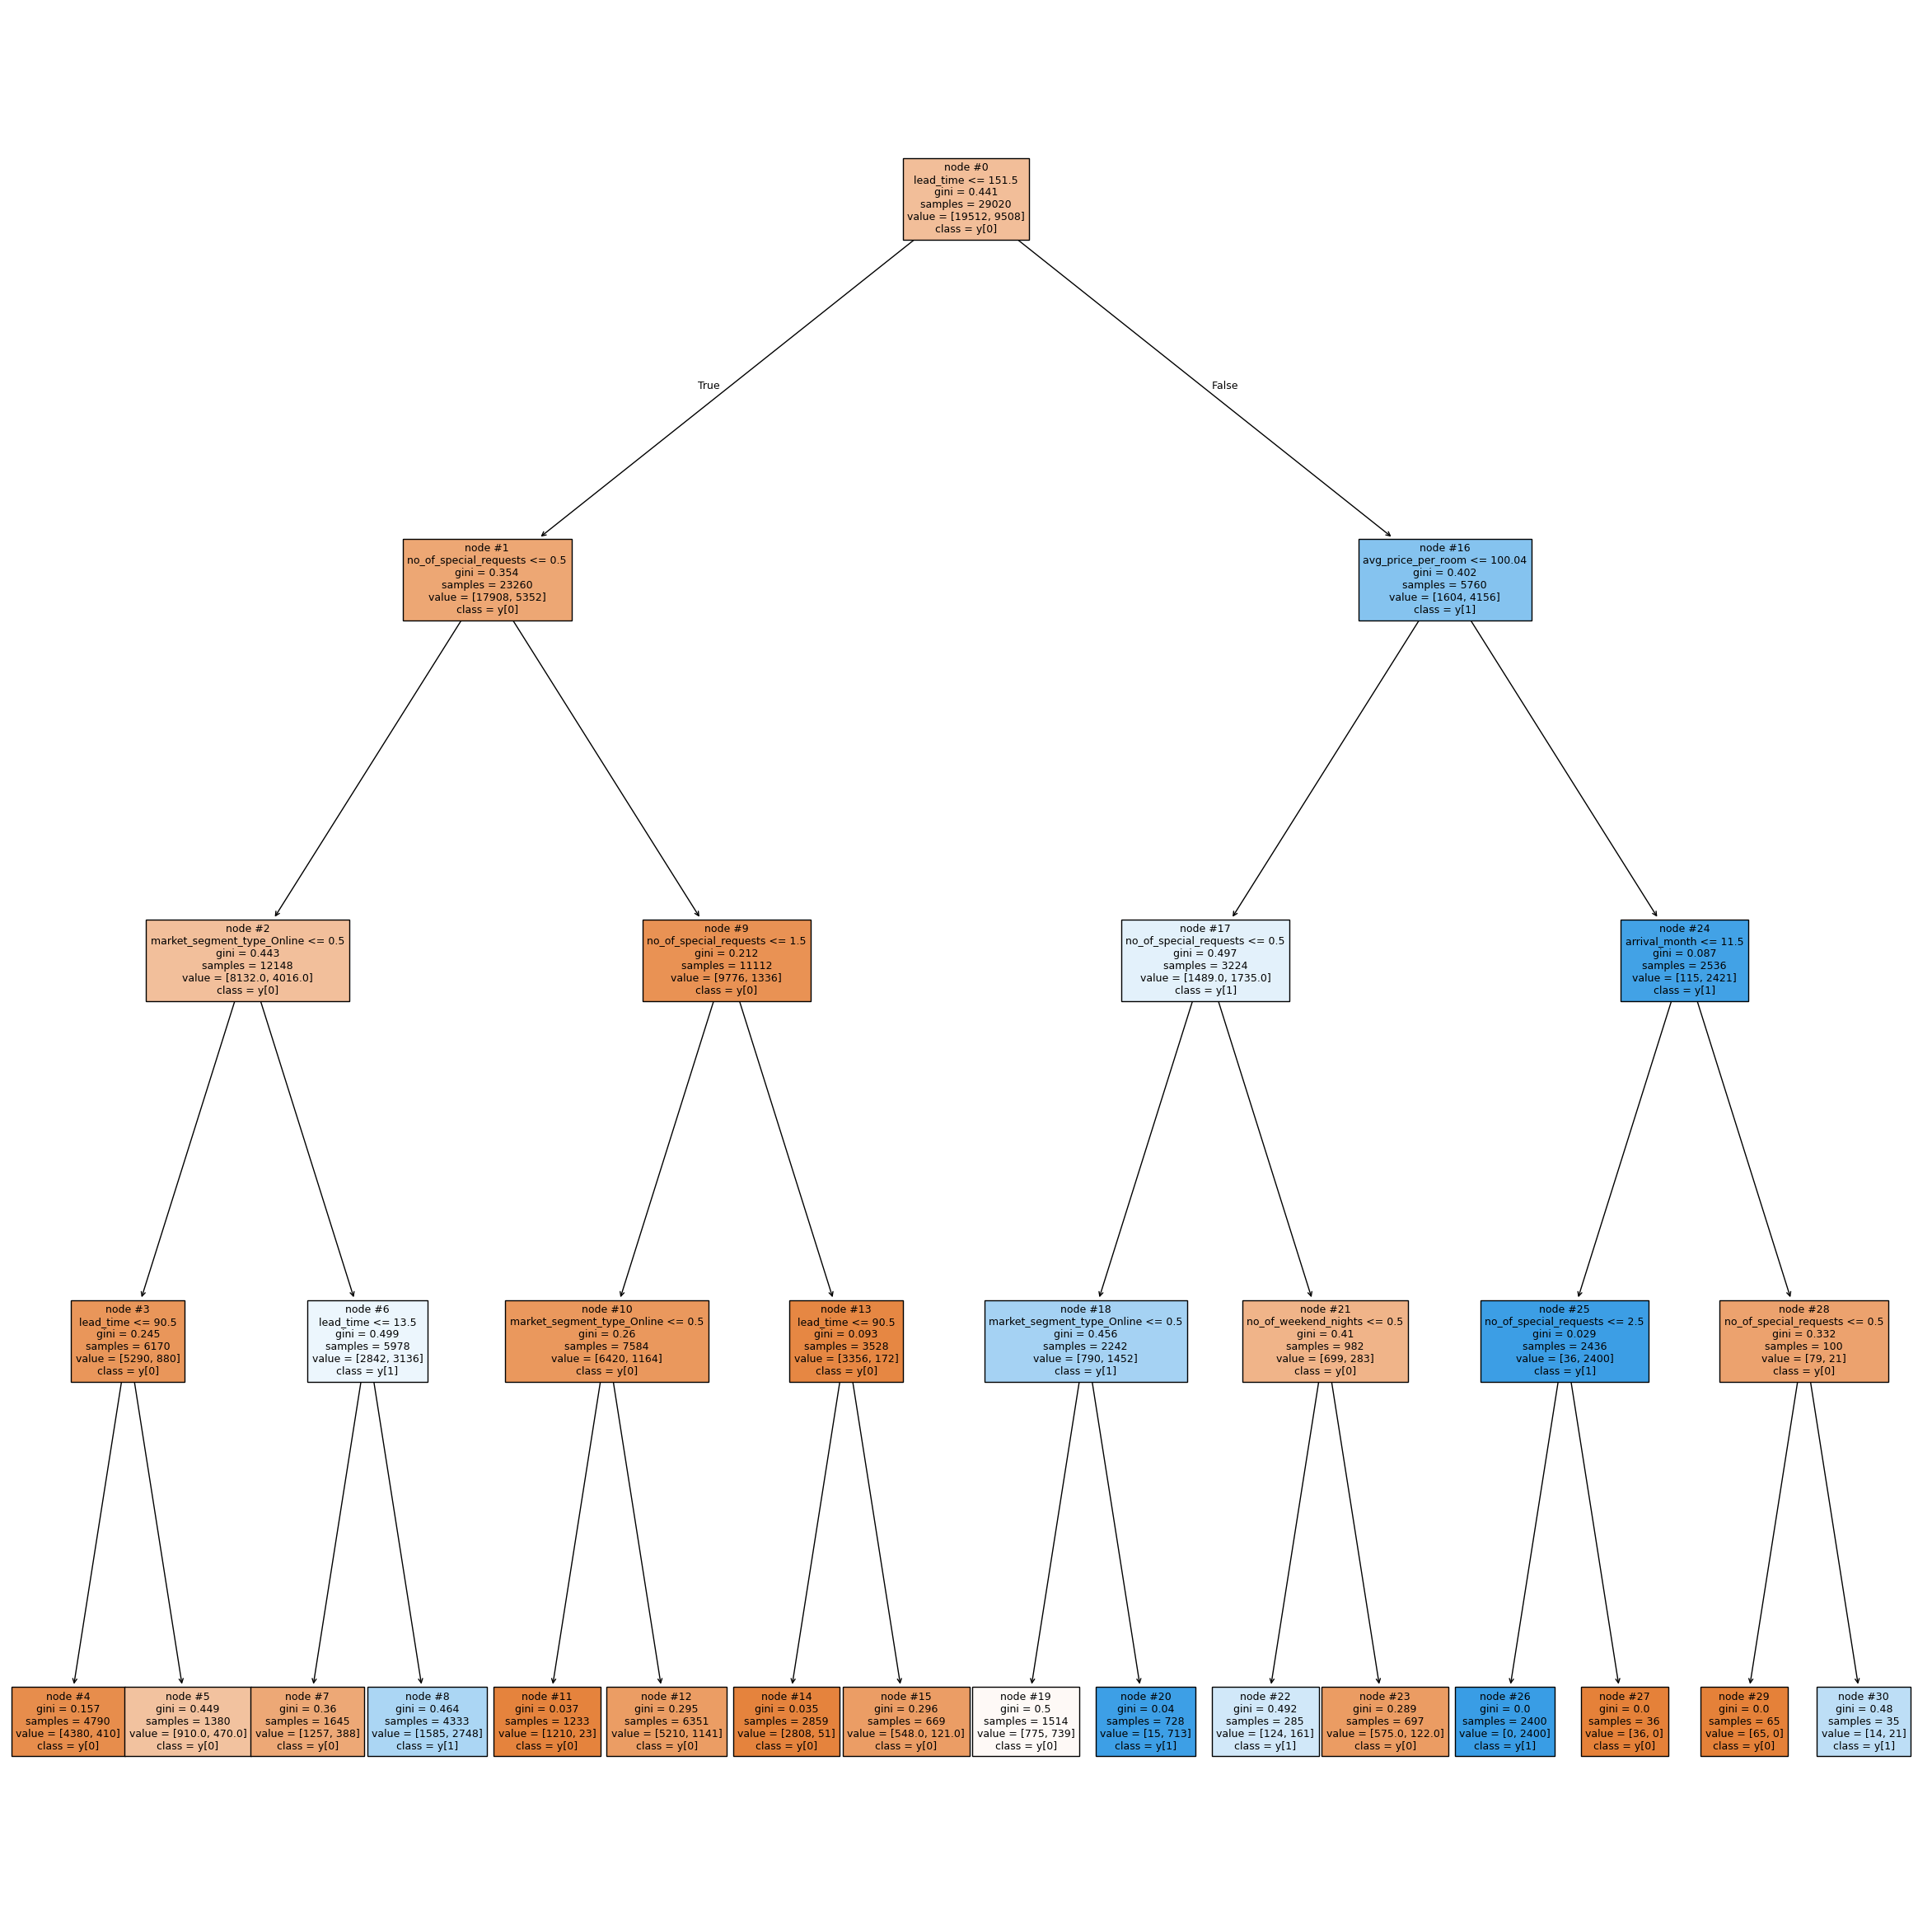

In [86]:
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

plt.figure(figsize=(30, 30))
plot_tree(dt, feature_names=X_train.columns.to_list(), filled=True, fontsize=9, node_ids=True, class_names=True)
plt.show()